# get results

In [2]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

In [3]:
def calculate_auroc_from_csv(file_path):
    """Calculate AUROC for a single CSV file"""
    try:
        # Load the CSV file
        df = pd.read_csv(file_path)

        # Check if the required columns exist
        required_columns = ['type', 'mean_score']
        if not all(col in df.columns for col in required_columns):
            return None, "Missing required columns (type and/or mean_score)"

        # Prepare data for ROC calculation
        # 1 for deployment (positive class), 0 for testing (negative class)
        y_true = (df['type'] == 'deployment').astype(int)

        # Use mean_score as the prediction score
        y_score = df['mean_score']

        # Calculate ROC curve points
        fpr, tpr, thresholds = roc_curve(y_true, y_score)
        roc_auc = auc(fpr, tpr)

        # Calculate optimal threshold (Youden's J statistic)
        optimal_idx = np.argmax(tpr - fpr)
        optimal_threshold = thresholds[optimal_idx]
        sensitivity = tpr[optimal_idx]
        specificity = 1-fpr[optimal_idx]

        return {
            'auroc': roc_auc,
            'optimal_threshold': optimal_threshold,
            'sensitivity': sensitivity,
            'specificity': specificity
        }, None

    except Exception as e:
        return None, str(e)

In [4]:
def process_all_csvs_in_directory(directory_path):
    """Process all CSV files in the given directory"""
    results = {}

    # Check if directory exists
    if not os.path.isdir(directory_path):
        print(f"Error: '{directory_path}' is not a valid directory.")
        return results

    # Get list of CSV files
    csv_files = [f for f in os.listdir(directory_path) if f.endswith('.csv')]

    if not csv_files:
        print(f"No CSV files found in {directory_path}")
        return results

    print(f"Found {len(csv_files)} CSV files in {directory_path}")
    print(f"{'File Name':<40} {'AUROC':<10} {'Threshold':<10} {'Sensitivity':<12} {'Specificity':<12}")
    print("-" * 90)

    # Process each CSV file
    for file_name in csv_files:
        file_path = os.path.join(directory_path, file_name)
        stats, error = calculate_auroc_from_csv(file_path)

        if error:
            print(f"{file_name:<40} Error: {error}")
        else:
            auroc = stats['auroc']
            threshold = stats['optimal_threshold']
            sensitivity = stats['sensitivity']
            specificity = stats['specificity']

            print(f"{file_name:<40} {auroc:.4f}    {threshold:.4f}    {sensitivity:.4f}      {specificity:.4f}")
            results[file_name] = stats

    # Find and print the file with the highest AUROC
    if results:
        # Peak AUROC
        best_file = max(results.items(), key=lambda x: x[1]['auroc'])
        print("\nHighest AUROC:")
        print(f"File: {best_file[0]}, AUROC: {best_file[1]['auroc']:.4f}")

        # Mean AUROC across all layers
        all_aurocs = [v['auroc'] for v in results.values()]
        mean_auroc = np.mean(all_aurocs)
        std_auroc = np.std(all_aurocs)
        peak_auroc = best_file[1]['auroc']
        concentration_ratio = peak_auroc / mean_auroc if mean_auroc > 0 else float('inf')

        print(f"\nSummary Statistics:")
        print(f"  Mean AUROC:          {mean_auroc:.4f} (std: {std_auroc:.4f})")
        print(f"  Peak AUROC:          {peak_auroc:.4f}")
        print(f"  Peak/Mean ratio:     {concentration_ratio:.3f}")
        print(f"  (ratio > 1 = signal concentrated at peak layer)")
        print(f"  (ratio near 1 = signal diffuse across all layers)")

    return results

In [5]:
directory_path = 'QWEN_32B_PROBE_RESULTS/'
results = process_all_csvs_in_directory(directory_path)

Found 63 CSV files in QWEN_32B_PROBE_RESULTS/
File Name                                AUROC      Threshold  Sensitivity  Specificity 
------------------------------------------------------------------------------------------
probe_stats_layer20.csv                  0.4572    -0.3305    0.6400      0.3850
probe_stats_layer34.csv                  0.4633    15.9862    0.0800      0.9800
probe_stats_layer35.csv                  0.4419    31.8724    0.0800      0.9800
probe_stats_layer21.csv                  0.3979    72.8973    0.0700      0.9850
probe_stats_layer37.csv                  0.4253    84.5096    0.0800      0.9850
probe_stats_layer23.csv                  0.4066    59.9057    0.0700      0.9850
probe_stats_layer22.csv                  0.3699    5.8037    0.0700      0.9800
probe_stats_layer36.csv                  0.4266    71.7635    0.0750      0.9850
probe_stats_layer32.csv                  0.4503    17.0890    0.0900      0.9850
probe_stats_layer26.csv                  0.438

In [ ]:
# Load the data
df = pd.read_csv('./QWEN_0.5B_PROBE_RESULTS/probe_stats_layer9.csv')

# Prepare data for ROC calculation
y_true = (df['type'] == 'deployment').astype(int)
y_score = df['mean_score']

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

# Create wider figure
plt.figure(figsize=(12, 6))

# Plot the ROC curve
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.3f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")

# Add text box with metrics
metrics_text = f'AUROC: {0.816}\nThreshold: {0.103}\nSensitivity: {0.690}\nSpecificity: {0.860}'
plt.text(0.05, 0.95, metrics_text,
         transform=plt.gca().transAxes,
         bbox=dict(facecolor='white', edgecolor='black', alpha=0.8),
         verticalalignment='top',
         fontfamily='monospace')

# Save as PDF
plt.savefig('roc_curve.pdf', format='pdf', bbox_inches='tight', dpi=300)

# Save as SVG
plt.savefig('roc_curve.svg', format='svg', bbox_inches='tight')

# Display the plot
plt.show()

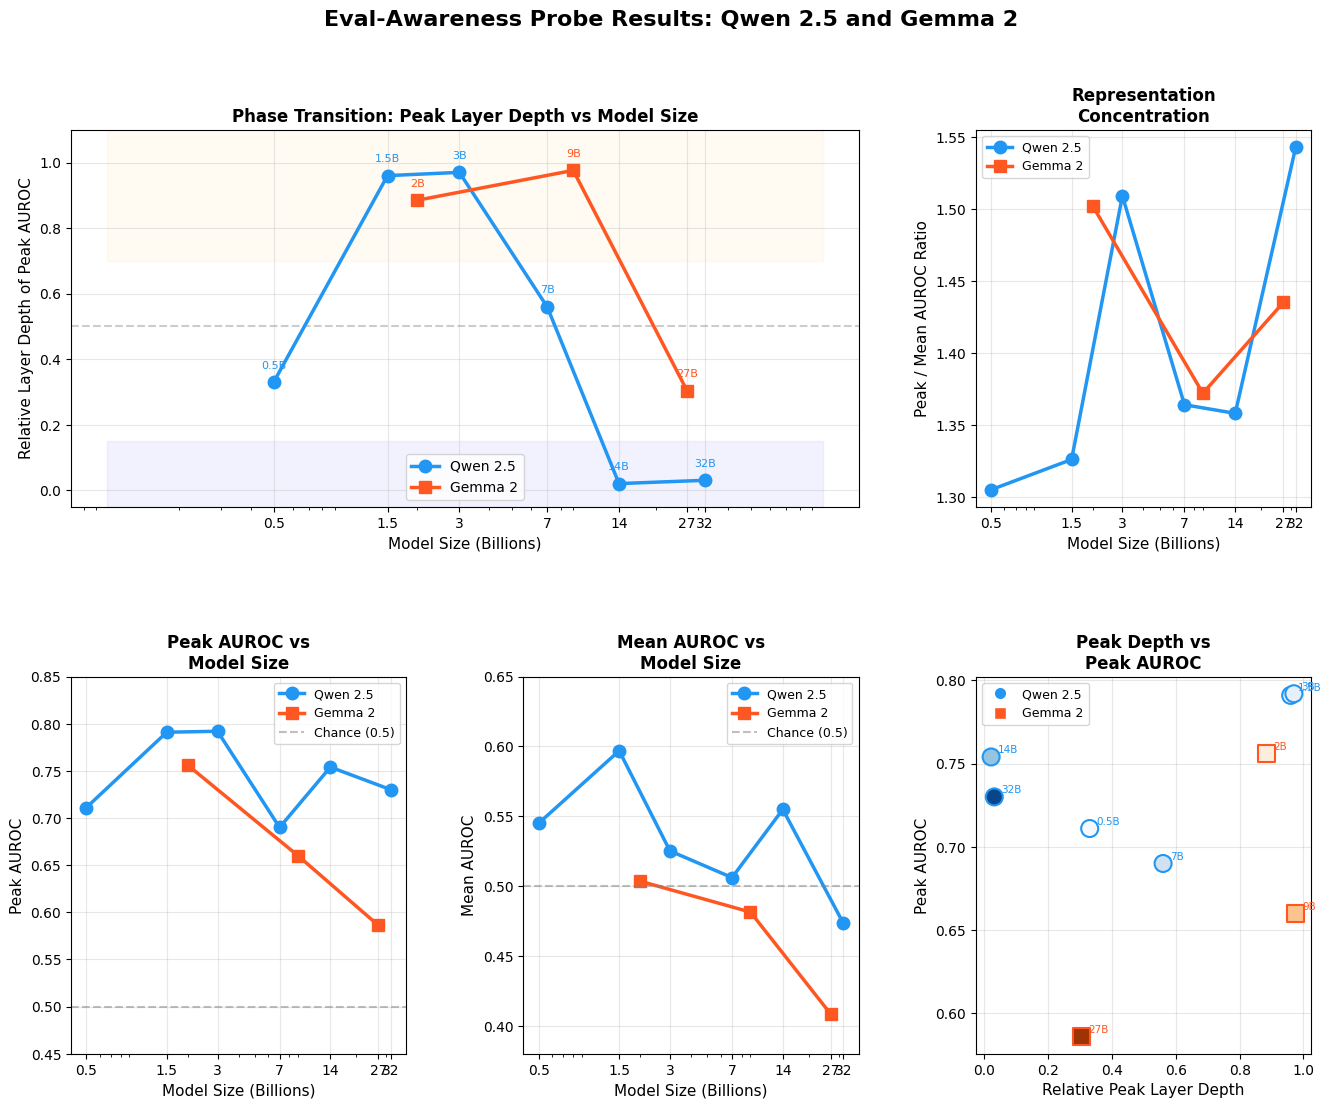

Saved as eval_awareness_results.png


In [6]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# Data
qwen_data = {
    'sizes': [0.5, 1.5, 3, 7, 14, 32],
    'peak_depth': [0.33, 0.96, 0.97, 0.56, 0.021, 0.031],
    'peak_auroc': [0.711, 0.791, 0.792, 0.690, 0.754, 0.730],
    'mean_auroc': [0.5450, 0.5969, 0.5252, 0.5061, 0.5549, 0.4734],
    'peak_mean_ratio': [1.305, 1.326, 1.509, 1.364, 1.358, 1.543],
}

gemma_data = {
    'sizes': [2, 9, 27],
    'peak_depth': [0.885, 0.976, 0.304],
    'peak_auroc': [0.756, 0.660, 0.586],
    'mean_auroc': [0.5035, 0.4814, 0.4082],
    'peak_mean_ratio': [1.502, 1.372, 1.435],
}

fig = plt.figure(figsize=(16, 12))
fig.suptitle('Eval-Awareness Probe Results: Qwen 2.5 and Gemma 2', 
             fontsize=16, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# Colors
qwen_color = '#2196F3'
gemma_color = '#FF5722'

# ── Plot 1: Peak Layer Depth vs Model Size ──────────────────────────────────
ax1 = fig.add_subplot(gs[0, :2])
ax1.plot(qwen_data['sizes'], qwen_data['peak_depth'], 
         'o-', color=qwen_color, linewidth=2.5, markersize=9, label='Qwen 2.5', zorder=3)
ax1.plot(gemma_data['sizes'], gemma_data['peak_depth'], 
         's-', color=gemma_color, linewidth=2.5, markersize=9, label='Gemma 2', zorder=3)

# Annotate Qwen points
for i, (s, d) in enumerate(zip(qwen_data['sizes'], qwen_data['peak_depth'])):
    ax1.annotate(f'{s}B', (s, d), textcoords='offset points', 
                 xytext=(0, 10), ha='center', fontsize=8, color=qwen_color)

# Annotate Gemma points
for i, (s, d) in enumerate(zip(gemma_data['sizes'], gemma_data['peak_depth'])):
    ax1.annotate(f'{s}B', (s, d), textcoords='offset points', 
                 xytext=(0, 10), ha='center', fontsize=8, color=gemma_color)

ax1.set_xscale('log')
ax1.set_xlabel('Model Size (Billions)', fontsize=11)
ax1.set_ylabel('Relative Layer Depth of Peak AUROC', fontsize=11)
ax1.set_title('Phase Transition: Peak Layer Depth vs Model Size', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.set_ylim(-0.05, 1.1)
ax1.axhline(y=0.5, color='gray', linestyle='--', alpha=0.4, label='Middle layers')
ax1.grid(True, alpha=0.3)
ax1.set_xticks([0.5, 1.5, 3, 7, 14, 27, 32])
ax1.set_xticklabels(['0.5', '1.5', '3', '7', '14', '27', '32'])
ax1.fill_between([0.1, 100], 0.7, 1.1, alpha=0.05, color='orange', label='Late layers')
ax1.fill_between([0.1, 100], -0.05, 0.15, alpha=0.05, color='blue', label='Early layers')

# ── Plot 2: Peak/Mean Ratio ─────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
ax2.plot(qwen_data['sizes'], qwen_data['peak_mean_ratio'], 
         'o-', color=qwen_color, linewidth=2.5, markersize=9, label='Qwen 2.5')
ax2.plot(gemma_data['sizes'], gemma_data['peak_mean_ratio'], 
         's-', color=gemma_color, linewidth=2.5, markersize=9, label='Gemma 2')
ax2.set_xscale('log')
ax2.set_xlabel('Model Size (Billions)', fontsize=11)
ax2.set_ylabel('Peak / Mean AUROC Ratio', fontsize=11)
ax2.set_title('Representation\nConcentration', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_xticks([0.5, 1.5, 3, 7, 14, 27, 32])
ax2.set_xticklabels(['0.5', '1.5', '3', '7', '14', '27', '32'])

# ── Plot 3: Peak AUROC vs Model Size ───────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(qwen_data['sizes'], qwen_data['peak_auroc'], 
         'o-', color=qwen_color, linewidth=2.5, markersize=9, label='Qwen 2.5')
ax3.plot(gemma_data['sizes'], gemma_data['peak_auroc'], 
         's-', color=gemma_color, linewidth=2.5, markersize=9, label='Gemma 2')
ax3.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, linewidth=1.5, label='Chance (0.5)')
ax3.set_xscale('log')
ax3.set_xlabel('Model Size (Billions)', fontsize=11)
ax3.set_ylabel('Peak AUROC', fontsize=11)
ax3.set_title('Peak AUROC vs\nModel Size', fontsize=12, fontweight='bold')
ax3.legend(fontsize=9)
ax3.set_ylim(0.45, 0.85)
ax3.grid(True, alpha=0.3)
ax3.set_xticks([0.5, 1.5, 3, 7, 14, 27, 32])
ax3.set_xticklabels(['0.5', '1.5', '3', '7', '14', '27', '32'])

# ── Plot 4: Mean AUROC vs Model Size ───────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(qwen_data['sizes'], qwen_data['mean_auroc'], 
         'o-', color=qwen_color, linewidth=2.5, markersize=9, label='Qwen 2.5')
ax4.plot(gemma_data['sizes'], gemma_data['mean_auroc'], 
         's-', color=gemma_color, linewidth=2.5, markersize=9, label='Gemma 2')
ax4.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, linewidth=1.5, label='Chance (0.5)')
ax4.set_xscale('log')
ax4.set_xlabel('Model Size (Billions)', fontsize=11)
ax4.set_ylabel('Mean AUROC', fontsize=11)
ax4.set_title('Mean AUROC vs\nModel Size', fontsize=12, fontweight='bold')
ax4.legend(fontsize=9)
ax4.set_ylim(0.38, 0.65)
ax4.grid(True, alpha=0.3)
ax4.set_xticks([0.5, 1.5, 3, 7, 14, 27, 32])
ax4.set_xticklabels(['0.5', '1.5', '3', '7', '14', '27', '32'])

# ── Plot 5: Peak Depth vs Peak AUROC scatter ────────────────────────────────
ax5 = fig.add_subplot(gs[1, 2])
scatter_qwen = ax5.scatter(qwen_data['peak_depth'], qwen_data['peak_auroc'],
                           c=qwen_data['sizes'], cmap='Blues', s=150,
                           vmin=0, vmax=35, zorder=3, edgecolors=qwen_color, linewidths=1.5)
scatter_gemma = ax5.scatter(gemma_data['peak_depth'], gemma_data['peak_auroc'],
                            c=gemma_data['sizes'], cmap='Oranges', s=150,
                            vmin=0, vmax=30, zorder=3, edgecolors=gemma_color, linewidths=1.5,
                            marker='s')

for i, (d, a, s) in enumerate(zip(qwen_data['peak_depth'], qwen_data['peak_auroc'], qwen_data['sizes'])):
    ax5.annotate(f'{s}B', (d, a), textcoords='offset points', 
                 xytext=(5, 3), ha='left', fontsize=7.5, color=qwen_color)

for i, (d, a, s) in enumerate(zip(gemma_data['peak_depth'], gemma_data['peak_auroc'], gemma_data['sizes'])):
    ax5.annotate(f'{s}B', (d, a), textcoords='offset points', 
                 xytext=(5, 3), ha='left', fontsize=7.5, color=gemma_color)

ax5.set_xlabel('Relative Peak Layer Depth', fontsize=11)
ax5.set_ylabel('Peak AUROC', fontsize=11)
ax5.set_title('Peak Depth vs\nPeak AUROC', fontsize=12, fontweight='bold')
ax5.grid(True, alpha=0.3)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=qwen_color, markersize=9, label='Qwen 2.5'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor=gemma_color, markersize=9, label='Gemma 2'),
]
ax5.legend(handles=legend_elements, fontsize=9)

plt.savefig('eval_awareness_results.png', dpi=150, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print("Saved as eval_awareness_results.png")